In [1]:
## This notebook is the initial setup for NISAR data ingestion

In [2]:
import io
import pandas as pd
from datetime import datetime
import re
import h5py
import requests
import earthaccess
import xarray as xr
import numpy as np
import h5netcdf
import rasterio
from rasterio.transform import from_origin
import matplotlib.pyplot as plt
import s3fs
from pprint import pprint

from nisar_utils import nisar_tmean

### Examples of how to query data

In [3]:
auth = earthaccess.login()

In [4]:
nisar_results = earthaccess.search_data(short_name = 'NISAR_L2_GUNW_BETA_V1', 
                                        temporal = ('2023-07-01 00:00:00', '2025-08-31 23:59:59'), # can also specify by time
                                        granule_name = '*T00888*', cloud_hosted=True) # here we filter by files with CRID value of *T00888*
                                        # bounding_box = (-106.62, 38.809, -106.54, 38.859)) 
print(pprint(nisar_results))

[]
None


In [5]:
import asf_search as asf

# Define your area of interest (example WKT)
wkt_area = 'POLYGON((-135.7 58.2,-136.6 58.1,-135.8 56.9,-134.6 56.1,-134.9 58.0,-135.7 58.2))'

# Define your search parameters
params = {
    'platform': asf.PLATFORM.NISAR,  # Specify the NISAR platform
    # 'shortName': ['NISAR_L1_SLC_P_GRD'], # Example short name if known
    # 'dataset': 'NISAR_L1_SLC', # Example dataset if known
    'intersectsWith': wkt_area,
    'start': '2024-01-01T00:00:00Z',
    'end': '2025-12-31T23:59:59Z',
    'maxResults': 10 # Limit the number of results for testing
}

# search
results = asf.search(**params)

# Print the results
for product in results:
    print(f"Granule Name: {product.properties['granuleName']}")
    print(f"Start Time: {product.properties['startTime']}")
    print(f"Platform: {product.properties['platform']}")
    print("-" * 20)

print(f"Found {len(results)} NISAR products.")

Found 0 NISAR products.


In [6]:
from shapely import wkt
# use earthaccess to search by polygon

# authenticate
earthaccess.login()

# define WKT polygon and compute a bounding box
geom = wkt.loads('POLYGON((-135.7 58.2,-136.6 58.1,-135.8 56.9,-134.6 56.1,-134.9 58.0,-135.7 58.2))')
minx, miny, maxx, maxy = geom.bounds
bbox = (minx, miny, maxx, maxy)

# Search granules
results = earthaccess.search_data(
    short_name="NISAR_L2_GCOV",
    bounding_box=bbox,
    cloud_hosted=True,# search cloud-hosted variants
    count=100 # number of granules to fetch (-1 = all)
)

print(f"Found {len(results)} granule(s).")

# print results
for granule in results:
    print(granule.id)
    links = granule.data_links()
    print("  Available links:", links)

Found 0 granule(s).


### From a list of sample data create a dataframe to simulate a pair of tracks

In [7]:
# Path to list of NISAR samples
links_file = "nisar_sample_data_path.txt"

# Read links
with open(links_file) as f:
    links = [line.strip() for line in f if line.strip()]

records = []

for link in links:
    # Extract filename
    filename = link.split("/")[-1]

    # Extract granule_id
    match_granule = re.search(r"(GCOV_\d+_\d+_A_\d+_\d+)", filename)
    granule_id = match_granule.group(1) if match_granule else None

    # Extract acquisition datetime (YYYYMMDDThhmmss)
    match_date = re.search(r"(\d{8}T\d{6})", filename)
    acq_datetime = None
    if match_date:
        acq_datetime = datetime.strptime(match_date.group(1), "%Y%m%dT%H%M%S")

    # original set
    records.append({
        "acq_datetime": acq_datetime,
        "granule_id": granule_id,
        "link": link
    })

    # modify name to simulate a different granule from the same data
    if granule_id:
        fake_granule = granule_id.replace("001_001", "002_002")
        records.append({
            "acq_datetime": acq_datetime,
            "granule_id": fake_granule,
            "link": link   # keep the original link unchanged as simulation
        })

# Build DataFrame
nisar_df = pd.DataFrame(records)

In [8]:
# preview
nisar_df

,acq_datetime,granule_id,link
0,2022-01-25 05:33:57,GCOV_001_001_A_000_2000,https://raw.githubusercontent.com/NISAR-Scienc...
1,2022-01-25 05:33:57,GCOV_002_002_A_000_2000,https://raw.githubusercontent.com/NISAR-Scienc...
2,2022-02-08 05:33:56,GCOV_001_001_A_000_2000,https://raw.githubusercontent.com/NISAR-Scienc...
3,2022-02-08 05:33:56,GCOV_002_002_A_000_2000,https://raw.githubusercontent.com/NISAR-Scienc...
4,2022-02-22 05:33:56,GCOV_001_001_A_000_2000,https://raw.githubusercontent.com/NISAR-Scienc...
5,2022-02-22 05:33:56,GCOV_002_002_A_000_2000,https://raw.githubusercontent.com/NISAR-Scienc...
6,2022-03-08 05:33:56,GCOV_001_001_A_000_2000,https://raw.githubusercontent.com/NISAR-Scienc...
7,2022-03-08 05:33:56,GCOV_002_002_A_000_2000,https://raw.githubusercontent.com/NISAR-Scienc...
8,2022-03-22 05:33:56,GCOV_001_001_A_000_2000,https://raw.githubusercontent.com/NISAR-Scienc...
9,2022-03-22 05:33:56,GCOV_002_002_A_000_2000,https://raw.githubusercontent.com/NISAR-Scienc...


### Given a dataframe with granules and links, create temporal mean by granule

In [9]:
# Generate means
nisar_tmean_df = nisar_tmean(nisar_df, which_pol="HHHH")


Processing granule: GCOV_001_001_A_000_2000
Opening https://raw.githubusercontent.com/NISAR-Science-Algorithms/NISAR_CropArea/main/tifton/GCOV/NISAR_L2_PR_GCOV_001_001_A_000_2000_SHNA_A_20220125T053357_20220125T053407_T00777_M_F_J_777.h5
Opening https://raw.githubusercontent.com/NISAR-Science-Algorithms/NISAR_CropArea/main/tifton/GCOV/NISAR_L2_PR_GCOV_001_001_A_000_2000_SHNA_A_20220208T053356_20220208T053406_T00777_M_F_J_777.h5
Opening https://raw.githubusercontent.com/NISAR-Science-Algorithms/NISAR_CropArea/main/tifton/GCOV/NISAR_L2_PR_GCOV_001_001_A_000_2000_SHNA_A_20220222T053356_20220222T053406_T00777_M_F_J_777.h5
Opening https://raw.githubusercontent.com/NISAR-Science-Algorithms/NISAR_CropArea/main/tifton/GCOV/NISAR_L2_PR_GCOV_001_001_A_000_2000_SHNA_A_20220308T053356_20220308T053406_T00777_M_F_J_777.h5
Opening https://raw.githubusercontent.com/NISAR-Science-Algorithms/NISAR_CropArea/main/tifton/GCOV/NISAR_L2_PR_GCOV_001_001_A_000_2000_SHNA_A_20220322T053356_20220322T053406_T0077

### Display a sample tmean. 

In [10]:
with rasterio.open(f'NISAR_GCOV_002_002_A_000_2000_HHHH_tmean_20220125T053357_20220726T053355.tif') as dset:
    HH = dset.read(1)

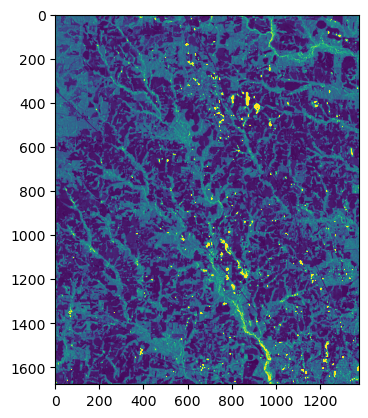

In [11]:
plt.imshow(HH, vmin=0, vmax=0.9, cmap='viridis')